# Spatial Maps — West Africa Precipitation Products
## Comparative Assessment 2001–2020

**Map 1** — Long-term mean annual precipitation (mm/yr) for all 6 products + GPCC reference  
**Map 2** — Spatial bias (product − GPCC) showing systematic over/under-estimation  

**Workflow:**  
1. Export mean annual images from GEE (one per product) → GeoTIFF  
2. Export GPCC mean from your local NetCDF files → GeoTIFF  
3. Plot both maps with cartopy, coordinate ticks, zone boundaries, station markers  

Run the GEE export cells first, download the GeoTIFFs to `MAPS_DIR`, then run the plotting cells.

In [3]:
from pathlib import Path

# ── Paths ────────────────────────────────────────────────
BASE_DIR  = Path(r'C:\Users\Gebruiker\OneDrive\Spain\Paper 1\precipitation_assessment')
DATA_DIR  = BASE_DIR / 'DATA_DIR'
MAPS_DIR  = BASE_DIR / 'maps'          # GeoTIFFs exported from GEE go here
GPCC_DIR  = DATA_DIR / 'gpcc_raw'      # your existing GPCC .nc files
FIGS_DIR  = BASE_DIR / 'figures'
MAPS_DIR.mkdir(exist_ok=True)
FIGS_DIR.mkdir(exist_ok=True)

# ── Study area bounding box ──────────────────────────────
LON_MIN, LON_MAX = -18.0, 16.5
LAT_MIN, LAT_MAX =   3.5, 21.5

# ── Products ─────────────────────────────────────────────
PRODUCTS = ['CHIRPS','ERA5_LAND','GPM_IMERG','MERRA2','PERSIANN_CDR','TERRACLIMATE']

PROD_LABELS = {
    'CHIRPS'       : 'CHIRPS\n(0.05°, Satellite-gauge)',
    'ERA5_LAND'    : 'ERA5-Land\n(0.1°, Reanalysis)',
    'GPM_IMERG'    : 'GPM IMERG\n(0.1°, Satellite-gauge)',
    'MERRA2'       : 'MERRA-2\n(~0.5°, Reanalysis)',
    'PERSIANN_CDR' : 'PERSIANN-CDR\n(0.25°, Satellite)',
    'TERRACLIMATE' : 'TerraClimate\n(~0.04°, Interp.)',
}

# ── Station coordinates ───────────────────────────────────
STATIONS = {
    'WA001':(-17.47,14.73,'Dakar'),
    'WA002':( -7.95,12.65,'Bamako'),
    'WA003':( -1.52,12.36,'Ouagadougou'),
    'WA004':(  2.17,13.51,'Niamey'),
    'WA005':(  7.33, 9.07,'Abuja'),
    'WA006':( -0.17, 5.56,'Accra'),
    'WA007':( -3.93, 5.35,'Abidjan'),
    'WA008':(-13.67, 9.53,'Conakry'),
    'WA009':(-13.23, 8.49,'Freetown'),
    'WA010':(-10.80, 6.30,'Monrovia'),
    'WA011':(  1.22, 6.13,'Lomé'),
    'WA012':(  2.42, 6.37,'Cotonou'),
    'WA013':(  8.52,12.05,'Kano'),
    'WA014':( -1.62, 6.69,'Kumasi'),
    'WA015':(-16.68,13.45,'Banjul'),
    'WA016':(-15.97,18.07,'Nouakchott'),
}

print('Config loaded.')
print(f'MAPS_DIR : {MAPS_DIR}')
print(f'GPCC_DIR : {GPCC_DIR}')
print(f'FIGS_DIR : {FIGS_DIR}')


Config loaded.
MAPS_DIR : C:\Users\Gebruiker\OneDrive\Spain\Paper 1\precipitation_assessment\maps
GPCC_DIR : C:\Users\Gebruiker\OneDrive\Spain\Paper 1\precipitation_assessment\DATA_DIR\gpcc_raw
FIGS_DIR : C:\Users\Gebruiker\OneDrive\Spain\Paper 1\precipitation_assessment\figures


## Step 1 — Export mean annual maps from GEE

Run this cell to submit GEE export tasks.  
Each exports a GeoTIFF of long-term mean mm/day clipped to West Africa.  
Download them from Google Drive to `MAPS_DIR` before running the plotting cells.

In [2]:
import ee
ee.Initialize(project='ee-desmond')

ASSET_BASE   = 'projects/ee-desmond/assets/'
DRIVE_FOLDER = 'WA_Maps'
START = '2001-01-01'
END   = '2020-12-31'
SCALE = 27830  # 0.25 degrees

ROI = ee.FeatureCollection('projects/ee-desmond/assets/west_africa_boundary0')\
        .geometry().simplify(maxError=5000)

# ── Product collection definitions (matches data_ingestion.py) ──
def get_mean_image(product):
    """Return long-term mean mm/day image for a product."""

    if product == 'CHIRPS':
        ic = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')\
              .filterDate(START, END).select('precipitation')
        return ic.mean().rename('precip_mm_day')

    elif product == 'ERA5_LAND':
        ic = ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')\
              .filterDate(START, END).select('total_precipitation_sum')
        def conv(img):
            d   = ee.Date(img.get('system:time_start'))
            dim = d.advance(1,'month').difference(d,'day')
            return img.multiply(1000).divide(dim).rename('precip_mm_day')\
                      .copyProperties(img,['system:time_start'])
        return ic.map(conv).mean().rename('precip_mm_day')

    elif product == 'GPM_IMERG':
        ic = ee.ImageCollection('NASA/GPM_L3/IMERG_MONTHLY_V07')\
              .filterDate(START, END).select('precipitation')
        return ic.mean().multiply(24).rename('precip_mm_day')

    elif product == 'MERRA2':
        # Load from pre-exported yearly climatology assets
        imgs = [ee.Image(f'{ASSET_BASE}climatology_MERRA2_{yr}')\
                  .reduce(ee.Reducer.mean()).rename('precip_mm_day')
                for yr in range(2001, 2021)]
        return ee.ImageCollection(imgs).mean().rename('precip_mm_day')

    elif product == 'PERSIANN_CDR':
        ic = ee.ImageCollection('NOAA/PERSIANN-CDR')\
              .filterDate(START, END).select('precipitation')
        return ic.mean().rename('precip_mm_day')

    elif product == 'TERRACLIMATE':
        ic = ee.ImageCollection('IDAHO_EPSCOR/TERRACLIMATE')\
              .filterDate(START, END).select('pr')
        def conv_terra(img):
            d   = ee.Date(img.get('system:time_start'))
            dim = d.advance(1,'month').difference(d,'day')
            return img.toFloat().divide(ee.Image.constant(dim)).rename('precip_mm_day')\
                      .copyProperties(img,['system:time_start'])
        return ic.map(conv_terra).mean().rename('precip_mm_day')


# ── Submit export tasks ────────────────────────────────────
PRODUCTS = ['CHIRPS','ERA5_LAND','GPM_IMERG','MERRA2','PERSIANN_CDR','TERRACLIMATE']
tasks = {}

for prod in PRODUCTS:
    img = get_mean_image(prod).multiply(365.25).clip(ROI)  # mm/day → mm/yr
    task = ee.batch.Export.image.toDrive(
        image          = img.toFloat(),
        description    = f'map_mean_annual_{prod}',
        folder         = DRIVE_FOLDER,
        fileNamePrefix = f'map_mean_annual_{prod}',
        region         = ROI,
        scale          = SCALE,
        crs            = 'EPSG:4326',
        maxPixels      = 1e13,
    )
    task.start()
    tasks[prod] = task
    print(f'  Submitted: map_mean_annual_{prod}.tif')

print(f'\n{len(tasks)} tasks submitted.')
print('Monitor: https://code.earthengine.google.com/tasks')
print(f'Download GeoTIFFs from Drive folder "{DRIVE_FOLDER}" to MAPS_DIR')


  Submitted: map_mean_annual_CHIRPS.tif
  Submitted: map_mean_annual_ERA5_LAND.tif
  Submitted: map_mean_annual_GPM_IMERG.tif
  Submitted: map_mean_annual_MERRA2.tif
  Submitted: map_mean_annual_PERSIANN_CDR.tif
  Submitted: map_mean_annual_TERRACLIMATE.tif

6 tasks submitted.
Monitor: https://code.earthengine.google.com/tasks
Download GeoTIFFs from Drive folder "WA_Maps" to MAPS_DIR


## Step 2 — Build GPCC reference GeoTIFF from local files

Uses the GPCC .nc files already downloaded by `download_gpcc.py`.  
Computes mean annual precipitation over 2001–2020 at 1.0° resolution.

In [3]:
import xarray as xr
import numpy as np
import rasterio
from rasterio.transform import from_bounds

GPCC_OUT = MAPS_DIR / 'map_mean_annual_GPCC.tif'

if GPCC_OUT.exists():
    print(f'Already exists: {GPCC_OUT.name} — delete it to regenerate')
else:
    spatial_stack = None
    lats = lons = None

    for yr in range(2001, 2021):
        # Try both naming conventions
        for fname in [
            f'full_data_daily_v2022_10_{yr}.nc',
            f'full_data_daily_v2022_{yr}.nc',
        ]:
            nc = GPCC_DIR / fname
            if nc.exists():
                break
        else:
            print(f'  {yr}: file not found — skipping')
            continue

        ds = xr.open_dataset(nc)

        # Auto-detect coordinate names
        lon_name = next((c for c in ds.coords if 'lon' in c.lower()), None)
        lat_name = next((c for c in ds.coords if 'lat' in c.lower()), None)
        var_name = next((v for v in ds.data_vars), None)

        if not all([lon_name, lat_name, var_name]):
            print(f'  {yr}: cannot find lon/lat/var — coords={list(ds.coords)}, vars={list(ds.data_vars)}')
            ds.close()
            continue

        lon_vals = ds[lon_name].values
        lat_vals = ds[lat_name].values
        lat_asc  = lat_vals[0] < lat_vals[-1]  # True if ascending

        # Clip to West Africa — handle both ascending and descending lat
        if lat_asc:
            da = ds[var_name].sel(
                {lon_name: slice(LON_MIN, LON_MAX),
                 lat_name: slice(LAT_MIN, LAT_MAX)}
            )
        else:
            da = ds[var_name].sel(
                {lon_name: slice(LON_MIN, LON_MAX),
                 lat_name: slice(LAT_MAX, LAT_MIN)}  # descending
            )

        if da.size == 0:
            print(f'  {yr}: empty after clip — lon range={lon_vals.min():.1f}–{lon_vals.max():.1f}, '
                  f'lat range={lat_vals.min():.1f}–{lat_vals.max():.1f}')
            ds.close()
            continue

        # Average over time dimension
        time_dim = [d for d in da.dims if 'time' in d.lower() or 'day' in d.lower()]
        if time_dim:
            annual_mean = da.mean(dim=time_dim[0]).values.astype(float)
        else:
            annual_mean = da.values.astype(float)

        # Mask fill values
        fill = ds[var_name].attrs.get('_FillValue',
               ds[var_name].attrs.get('missing_value', -9999))
        annual_mean[annual_mean == fill] = np.nan

        if spatial_stack is None:
            spatial_stack = annual_mean[np.newaxis]
            lats = da[lat_name].values
            lons = da[lon_name].values
        else:
            spatial_stack = np.concatenate(
                [spatial_stack, annual_mean[np.newaxis]], axis=0)

        print(f'  {yr}: loaded  shape={annual_mean.shape}  '
              f'range={np.nanmin(annual_mean):.2f}–{np.nanmax(annual_mean):.2f} mm/day')
        ds.close()

    if spatial_stack is None:
        print('ERROR: no years loaded — check GPCC_DIR path and file names')
    else:
        # Mean over all years → mm/day × 365.25 → mm/yr
        gpcc_mean_mmyr = np.nanmean(spatial_stack, axis=0) * 365.25

        print(f'\nGPCC mean annual range: {np.nanmin(gpcc_mean_mmyr):.1f} – '
              f'{np.nanmax(gpcc_mean_mmyr):.1f} mm/yr')
        print(f'Grid shape: {gpcc_mean_mmyr.shape}  '
              f'lons: {lons.min():.2f}–{lons.max():.2f}  '
              f'lats: {lats.min():.2f}–{lats.max():.2f}')

        # Write GeoTIFF — rasterio always expects data in N→S order
        if lats[0] < lats[-1]:   # ascending → flip
            gpcc_mean_mmyr = np.flipud(gpcc_mean_mmyr)
            lats = lats[::-1]

        transform = from_bounds(
            lons.min(), lats.min(), lons.max(), lats.max(),
            gpcc_mean_mmyr.shape[1], gpcc_mean_mmyr.shape[0]
        )
        with rasterio.open(
            GPCC_OUT, 'w', driver='GTiff',
            height=gpcc_mean_mmyr.shape[0],
            width=gpcc_mean_mmyr.shape[1],
            count=1, dtype='float32',
            crs='EPSG:4326', transform=transform,
            nodata=np.nan
        ) as dst:
            dst.write(gpcc_mean_mmyr.astype('float32'), 1)

        print(f'\nSaved: {GPCC_OUT.name}')

  2001: loaded  shape=(19, 35)  range=0.00–9.46 mm/day
  2002: loaded  shape=(19, 35)  range=0.00–9.99 mm/day
  2003: loaded  shape=(19, 35)  range=0.02–10.54 mm/day
  2004: loaded  shape=(19, 35)  range=0.01–8.68 mm/day
  2005: loaded  shape=(19, 35)  range=0.02–9.48 mm/day
  2006: loaded  shape=(19, 35)  range=0.03–11.91 mm/day
  2007: loaded  shape=(19, 35)  range=0.00–9.65 mm/day
  2008: loaded  shape=(19, 35)  range=0.02–9.19 mm/day
  2009: loaded  shape=(19, 35)  range=0.00–8.02 mm/day
  2010: loaded  shape=(19, 35)  range=0.02–10.36 mm/day
  2011: loaded  shape=(19, 35)  range=0.01–9.56 mm/day
  2012: loaded  shape=(19, 35)  range=0.02–9.40 mm/day
  2013: loaded  shape=(19, 35)  range=0.01–12.14 mm/day
  2014: loaded  shape=(19, 35)  range=0.00–9.75 mm/day
  2015: loaded  shape=(19, 35)  range=0.02–8.99 mm/day
  2016: loaded  shape=(19, 35)  range=0.01–10.48 mm/day
  2017: loaded  shape=(19, 35)  range=0.00–10.52 mm/day
  2018: loaded  shape=(19, 35)  range=0.03–8.39 mm/day
  20

C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_1904\1728694417.py:89: RuntimeWarning: Mean of empty slice
  gpcc_mean_mmyr = np.nanmean(spatial_stack, axis=0) * 365.25



Saved: map_mean_annual_GPCC.tif


## Step 3 — Load all GeoTIFFs for plotting

In [5]:
import rasterio
import numpy as np
from rasterio.warp import reproject, Resampling

def load_tif(path):
    """Load a GeoTIFF and return (data_2d, extent[W,E,S,N])."""
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            data[data == nodata] = np.nan
        bounds = src.bounds
        extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    return data, extent


# Load products
rasters = {}
missing = []
for prod in PRODUCTS:
    tif = MAPS_DIR / f'map_mean_annual_{prod}.tif'
    if tif.exists():
        rasters[prod], _ = load_tif(tif)
        print(f'  {prod}: {rasters[prod].shape}  '
              f'range {np.nanmin(rasters[prod]):.0f}–{np.nanmax(rasters[prod]):.0f} mm/yr')
    else:
        missing.append(prod)
        print(f'  MISSING: {tif.name}')

# Load GPCC reference
gpcc_tif = MAPS_DIR / 'map_mean_annual_GPCC.tif'
if gpcc_tif.exists():
    gpcc_data, gpcc_extent = load_tif(gpcc_tif)
    print(f'  GPCC: {gpcc_data.shape}  '
          f'range {np.nanmin(gpcc_data):.0f}–{np.nanmax(gpcc_data):.0f} mm/yr')
else:
    print('GPCC GeoTIFF missing — run Step 2 first')

if missing:
    print(f'\nStill missing: {missing}')
    print('Run Step 1 GEE exports and download the TIFFs before plotting.')
else:
    print('\nAll rasters loaded — ready to plot.')


  CHIRPS: (164, 228)  range 0–3863 mm/yr
  ERA5_LAND: (164, 228)  range 2–19405 mm/yr
  GPM_IMERG: (164, 228)  range 4–4304 mm/yr
  MERRA2: (164, 228)  range 2–3634 mm/yr
  PERSIANN_CDR: (164, 228)  range 11–3156 mm/yr
  TERRACLIMATE: (164, 228)  range 1–4291 mm/yr
  GPCC: (19, 35)  range 11–3169 mm/yr

All rasters loaded — ready to plot.


## Map 1 — Mean annual precipitation (mm/yr)

6-panel layout (2 rows × 3 cols) + GPCC reference panel.  
Coordinate ticks in degrees, ecological zone boundaries, station markers.

c:\Users\Gebruiker\anaconda3\envs\geospatial\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
c:\Users\Gebruiker\anaconda3\envs\geospatial\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
c:\Users\Gebruiker\anaconda3\envs\geospatial\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
c:\Users\Gebruiker\anaconda3\envs\geospatial\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
c:\Users\Gebruiker\anaconda3\envs\geospa

Saved: map01_mean_annual_precip.png


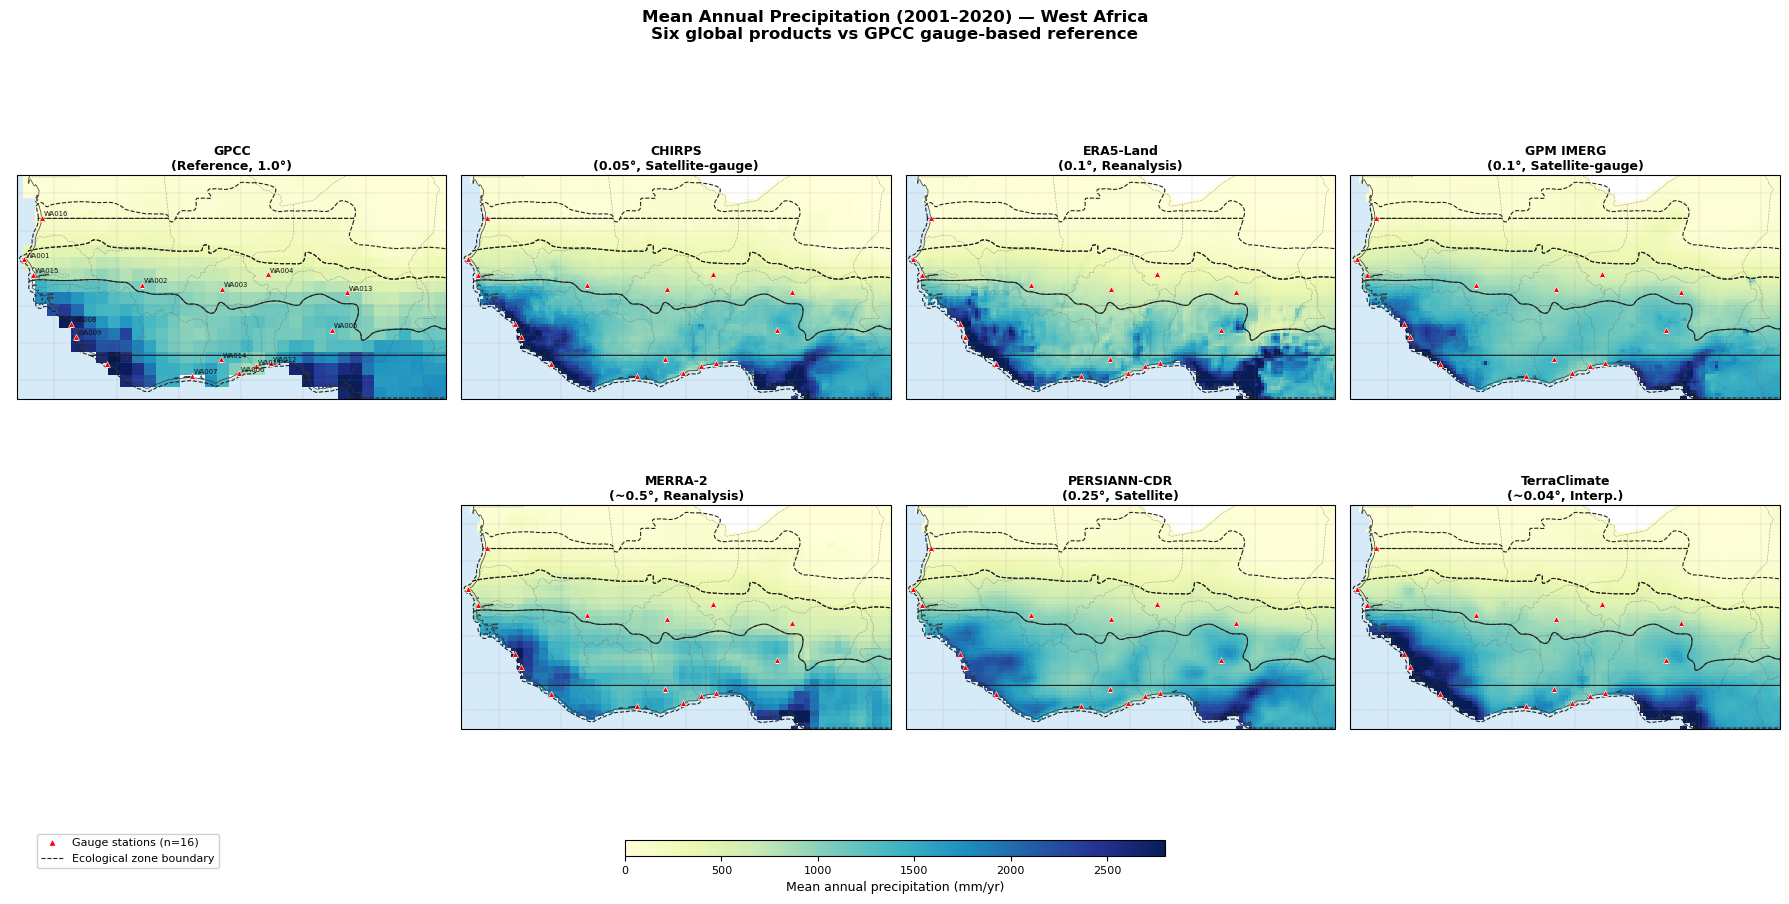

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import numpy as np
from pathlib import Path

# ── Shared settings ───────────────────────────────────────
PROJ   = ccrs.PlateCarree()
EXTENT = [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]
XTICKS = [-15, -10, -5, 0, 5, 10, 15]
YTICKS = [5, 8, 11, 14, 17, 20]

# Colormap and range for annual precip
PRECIP_CMAP = 'YlGnBu'
VMIN, VMAX  = 0, 2800   # mm/yr — adjust if needed

# Load zone boundaries
zone_shp = BASE_DIR / 'ecological_zones_5class' / 'ecological_zones_5class.shp'
zones_gdf = gpd.read_file(zone_shp) if zone_shp.exists() else None
if zones_gdf is None:
    print('Zone shapefile not found — zone boundaries will be skipped')


def add_map_elements(ax, title, show_ylabel=False, show_xlabel=False):
    """Add coastlines, borders, gridlines, ticks, and labels to an axis."""
    ax.set_extent(EXTENT, crs=PROJ)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='#333333')
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, color='#555555', linestyle=':')
    ax.add_feature(cfeature.OCEAN,     facecolor='#D6EAF8', zorder=0)
    ax.add_feature(cfeature.LAND,      facecolor='none',    zorder=0)

    # Zone boundaries
    if zones_gdf is not None:
        for _, zone in zones_gdf.iterrows():
            ax.add_geometries(
                [zone.geometry], crs=PROJ,
                facecolor='none', edgecolor='#222222',
                linewidth=0.8, linestyle='--'
            )

    # Coordinate gridlines with degree ticks
    gl = ax.gridlines(
        crs=PROJ, draw_labels=True,
        xlocs=XTICKS, ylocs=YTICKS,
        linewidth=0.3, color='gray', alpha=0.5, linestyle='--'
    )
    gl.top_labels    = False
    gl.right_labels  = False
    gl.left_labels   = show_ylabel
    gl.bottom_labels = show_xlabel
    gl.xlabel_style  = {'size': 7, 'color': '#333333'}
    gl.ylabel_style  = {'size': 7, 'color': '#333333'}
    gl.xformatter = mticker.FixedFormatter([f'{abs(x)}°W' if x<0 else f'{x}°E' for x in XTICKS])
    gl.yformatter = mticker.FixedFormatter([f'{y}°N' for y in YTICKS])

    ax.set_title(title, fontsize=9, fontweight='bold', pad=4)


def plot_stations(ax, label_stations=False):
    """Plot gauge station markers."""
    lons = [v[0] for v in STATIONS.values()]
    lats = [v[1] for v in STATIONS.values()]
    ax.scatter(lons, lats, s=18, c='red', marker='^',
               transform=PROJ, zorder=5,
               edgecolors='white', linewidths=0.4,
               label='Gauge stations')
    if label_stations:
        for sid, (lon, lat, name) in STATIONS.items():
            ax.text(lon+0.15, lat+0.15, sid, fontsize=5,
                    transform=PROJ, zorder=6, color='#111111')


# ── Build figure ──────────────────────────────────────────
# Layout: GPCC + 6 products = 7 panels → 2 rows × 4 cols
# Row 0: GPCC (reference), CHIRPS, ERA5_LAND, GPM_IMERG
# Row 1: [empty], MERRA2, PERSIANN_CDR, TERRACLIMATE
panel_order = [
    [('GPCC','GPCC\n(Reference, 1.0°)'), ('CHIRPS', PROD_LABELS['CHIRPS']),
     ('ERA5_LAND', PROD_LABELS['ERA5_LAND']), ('GPM_IMERG', PROD_LABELS['GPM_IMERG'])],
    [(None,None), ('MERRA2', PROD_LABELS['MERRA2']),
     ('PERSIANN_CDR', PROD_LABELS['PERSIANN_CDR']),
     ('TERRACLIMATE', PROD_LABELS['TERRACLIMATE'])],
]

fig = plt.figure(figsize=(18, 9))
fig.patch.set_facecolor('white')

axes = []
for row in range(2):
    for col in range(4):
        ax = fig.add_subplot(
            2, 4, row*4 + col + 1,
            projection=PROJ
        )
        axes.append((row, col, ax))

img_mappable = None

for row_idx, row_panels in enumerate(panel_order):
    for col_idx, (prod_key, title) in enumerate(row_panels):
        ax_idx = next(ax for r,c,ax in axes if r==row_idx and c==col_idx)

        if prod_key is None:
            ax_idx.set_visible(False)
            continue

        show_y = (col_idx == 0)
        show_x = (row_idx == 1)
        add_map_elements(ax_idx, title, show_y, show_x)

        # Load raster
        if prod_key == 'GPCC':
            data = gpcc_data
            extent_plot = gpcc_extent
        else:
            tif = MAPS_DIR / f'map_mean_annual_{prod_key}.tif'
            if not tif.exists():
                ax_idx.text(0.5, 0.5, f'{prod_key}\nNot yet downloaded',
                            ha='center', va='center', transform=ax_idx.transAxes,
                            fontsize=8, color='gray')
                continue
            data, extent_plot = load_tif(tif)

        im = ax_idx.imshow(
            data, origin='upper',
            extent=extent_plot,
            transform=PROJ,
            cmap=PRECIP_CMAP,
            vmin=VMIN, vmax=VMAX,
            interpolation='nearest',
            zorder=1
        )
        if img_mappable is None:
            img_mappable = im

        plot_stations(ax_idx, label_stations=(prod_key=='GPCC'))

        # Panel letter label
        # label = chr(65 + row_idx*4 + col_idx)  # A, B, C...
        # ax_idx.text(0.02, 0.97, f'({label})', transform=ax_idx.transAxes,
        #             fontsize=9, fontweight='bold', va='top',
        #             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

# Shared colorbar
cbar_ax = fig.add_axes([0.35, 0.04, 0.30, 0.018])
cbar = fig.colorbar(img_mappable, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Mean annual precipitation (mm/yr)', fontsize=9)
cbar.ax.tick_params(labelsize=8)

# Legend for stations
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='^', color='w', markerfacecolor='red',
           markersize=6, label='Gauge stations (n=16)'),
    Line2D([0],[0], color='#222222', lw=0.8, linestyle='--',
           label='Ecological zone boundary'),
]
fig.legend(handles=legend_elements, loc='lower left',
           bbox_to_anchor=(0.02, 0.02), fontsize=8, framealpha=0.9)

fig.suptitle(
    'Mean Annual Precipitation (2001–2020) — West Africa\n'
    'Six global products vs GPCC gauge-based reference',
    fontsize=12, fontweight='bold', y=0.98
)

fig.tight_layout(rect=[0, 0.07, 1, 0.96])
out = FIGS_DIR / 'map01_mean_annual_precip.png'
fig.savefig(out, dpi=300, bbox_inches='tight', facecolor='white')
print(f'Saved: {out.name}')
plt.show()


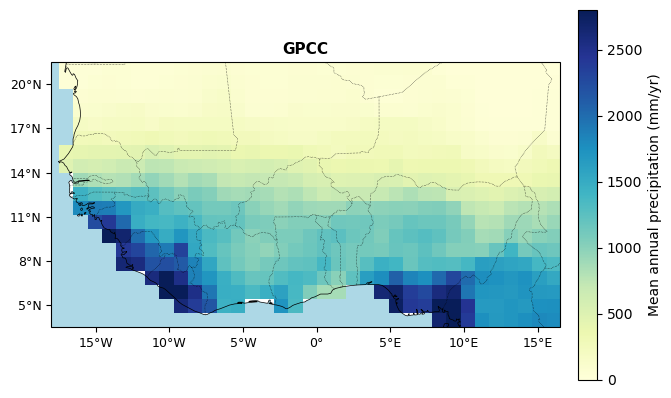

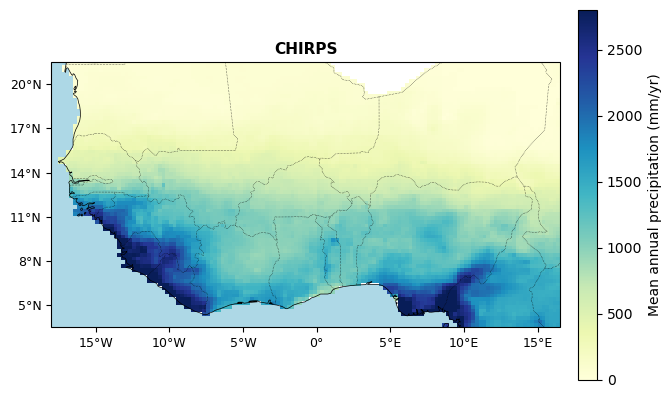

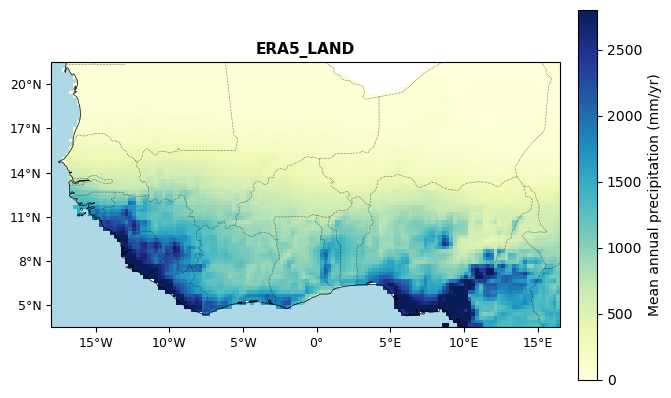

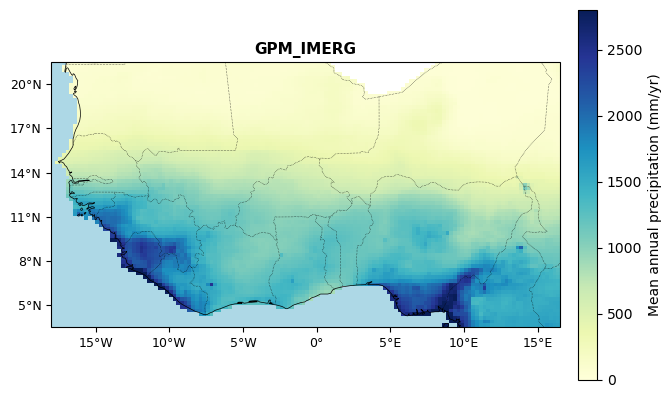

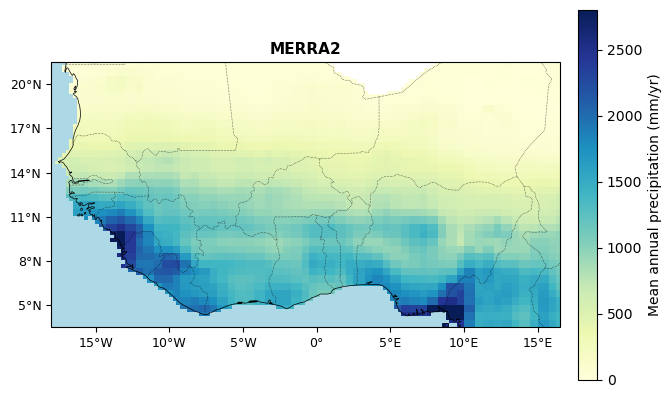

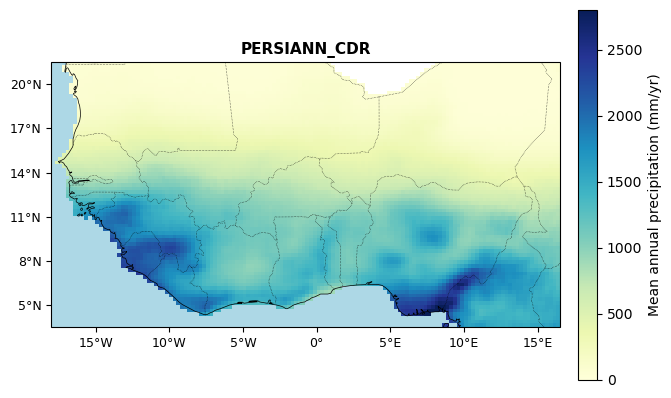

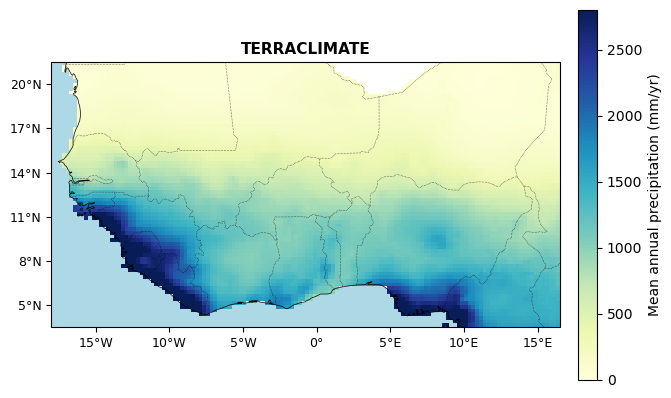

In [33]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import numpy as np

PROJ   = ccrs.PlateCarree()
EXTENT = [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]
XTICKS = [-15, -10, -5, 0, 5, 10, 15]
YTICKS = [5, 8, 11, 14, 17, 20]

PRECIP_CMAP = 'YlGnBu'
VMIN, VMAX  = 0, 2800

products = [('GPCC', gpcc_data, gpcc_extent)]
for prod_key in ['CHIRPS', 'ERA5_LAND', 'GPM_IMERG', 'MERRA2', 'PERSIANN_CDR', 'TERRACLIMATE']:
    tif = MAPS_DIR / f'map_mean_annual_{prod_key}.tif'
    if tif.exists():
        data, extent_plot = load_tif(tif)
        products.append((prod_key, data, extent_plot))
    else:
        print(f'{prod_key} not found: {tif}')

for title, data, extent_plot in products:
    fig = plt.figure(figsize=(8, 6))
    ax = plt.axes(projection=PROJ)

    ax.set_extent(EXTENT, crs=PROJ)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=':')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='none', zorder=0)

    # keep gaps from expanding
    if np.ma.isMaskedArray(data):
        plot_data = data
    else:
        plot_data = np.ma.masked_invalid(data)

    im = ax.imshow(
        plot_data,
        origin='upper',
        extent=extent_plot,
        transform=PROJ,
        cmap=PRECIP_CMAP,
        vmin=VMIN,
        vmax=VMAX,
        interpolation='nearest',  # try 'nearest' if you want zero visual spreading
        resample=False
    )
# 'hanning', 'quadric', 'bilinear', 'spline36', 'antialiased', 'spline16', 'hermite', 'sinc', 'bicubic', 'none', 'nearest', 'bessel', 'kaiser', 'blackman', 'gaussian', 'lanczos', 'hamming', 'catrom'',  
    ax.set_xticks(XTICKS, crs=PROJ)
    ax.set_yticks(YTICKS, crs=PROJ)
    ax.xaxis.set_major_formatter(LongitudeFormatter(degree_symbol='°'))
    ax.yaxis.set_major_formatter(LatitudeFormatter(degree_symbol='°'))
    ax.tick_params(labelsize=9)

    ax.set_title(title, fontsize=11, fontweight='bold')

    cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.03)
    cbar.set_label('Mean annual precipitation (mm/yr)')

    plt.show()

## Map 2 — Spatial bias relative to GPCC (mm/yr)

5-panel layout (one per satellite/reanalysis product).  
Diverging colormap: red = product wetter, blue = drier than GPCC.

c:\Users\Gebruiker\anaconda3\envs\geospatial\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
c:\Users\Gebruiker\anaconda3\envs\geospatial\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
c:\Users\Gebruiker\anaconda3\envs\geospatial\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
c:\Users\Gebruiker\anaconda3\envs\geospatial\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
c:\Users\Gebruiker\anaconda3\envs\geospa

CHIRPS: bias range -1116 to 2803 mm/yr  |  mean bias = 304.5 mm/yr
ERA5_LAND: bias range -1088 to 18414 mm/yr  |  mean bias = 244.9 mm/yr
GPM_IMERG: bias range -1037 to 3239 mm/yr  |  mean bias = 318.3 mm/yr
MERRA2: bias range -1392 to 2680 mm/yr  |  mean bias = 260.2 mm/yr
PERSIANN_CDR: bias range -1040 to 2175 mm/yr  |  mean bias = 324.0 mm/yr
TERRACLIMATE: bias range -1129 to 3196 mm/yr  |  mean bias = 280.1 mm/yr
Saved: map02_spatial_bias_vs_gpcc.png


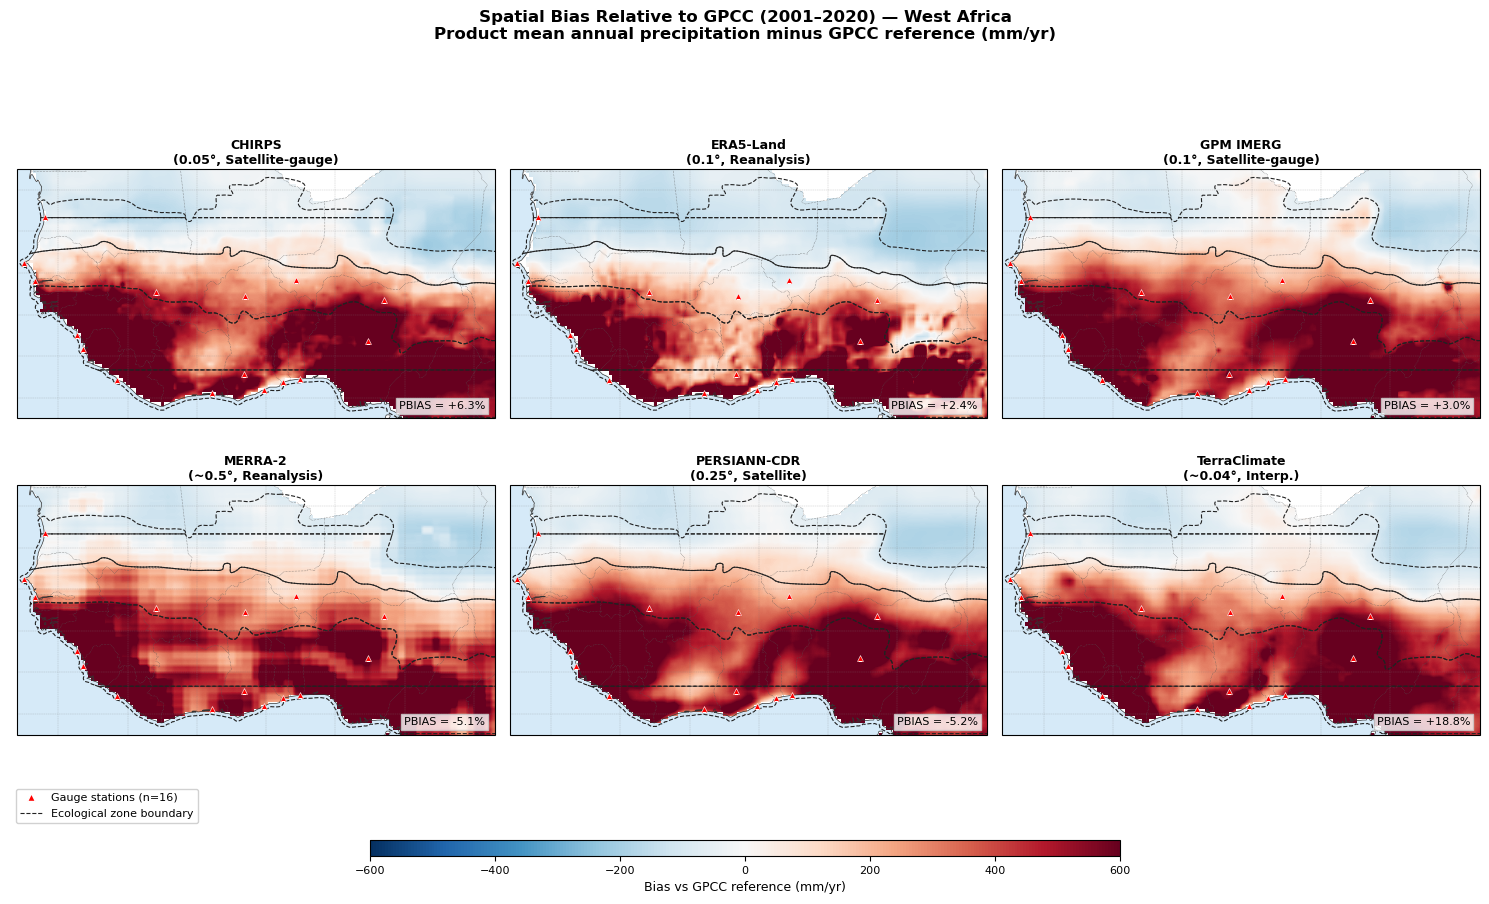

In [9]:
from matplotlib.colors import TwoSlopeNorm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

# Bias colormap settings
BIAS_CMAP = 'RdBu_r'  # red = positive (product wetter), blue = negative (drier)
BIAS_MAX  = 600       # mm/yr — adjust based on your data range

bias_norm = TwoSlopeNorm(vmin=-BIAS_MAX, vcenter=0, vmax=BIAS_MAX)

# Layout: 2 rows × 3 cols, last panel = empty or summary stats
# Products for bias: all 6 vs GPCC
bias_order = [
    [('CHIRPS', PROD_LABELS['CHIRPS']),
     ('ERA5_LAND', PROD_LABELS['ERA5_LAND']),
     ('GPM_IMERG', PROD_LABELS['GPM_IMERG'])],
    [('MERRA2', PROD_LABELS['MERRA2']),
     ('PERSIANN_CDR', PROD_LABELS['PERSIANN_CDR']),
     ('TERRACLIMATE', PROD_LABELS['TERRACLIMATE'])],
]

fig2, axs2 = plt.subplots(
    2, 3, figsize=(15, 9),
    subplot_kw={'projection': PROJ}
)
fig2.patch.set_facecolor('white')

bias_mappable = None

for row_idx, row_panels in enumerate(bias_order):
    for col_idx, (prod_key, title) in enumerate(row_panels):
        ax = axs2[row_idx][col_idx]
        show_y = (col_idx == 0)
        show_x = (row_idx == 1)
        add_map_elements(ax, title, show_y, show_x)

        tif = MAPS_DIR / f'map_mean_annual_{prod_key}.tif'
        if not tif.exists():
            ax.text(0.5, 0.5, f'{prod_key}\nNot yet downloaded',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=8, color='gray')
            continue

        prod_data, prod_extent = load_tif(tif)

        # Regrid GPCC to product resolution for subtraction
        # Simple approach: resize GPCC to match product array
        from scipy.ndimage import zoom
        if gpcc_data.shape != prod_data.shape:
            zy = prod_data.shape[0] / gpcc_data.shape[0]
            zx = prod_data.shape[1] / gpcc_data.shape[1]
            gpcc_resized = zoom(gpcc_data, (zy, zx), order=1, prefilter=False)
        else:
            gpcc_resized = gpcc_data

        bias = prod_data - gpcc_resized
        print(f'{prod_key}: bias range {np.nanmin(bias):.0f} to {np.nanmax(bias):.0f} mm/yr'
              f'  |  mean bias = {np.nanmean(bias):.1f} mm/yr')

        im = ax.imshow(
            bias, origin='upper',
            extent=prod_extent,
            transform=PROJ,
            cmap=BIAS_CMAP,
            norm=bias_norm,
            interpolation='bilinear',
            zorder=1
        )
        if bias_mappable is None:
            bias_mappable = im

        plot_stations(ax)

        # PBIAS annotation from validation data
        import pandas as pd
        vbz = pd.read_csv(DATA_DIR / 'validation_by_zone.csv')
        # West Africa pooled PBIAS from validation_overall
        vo  = pd.read_csv(DATA_DIR / 'validation_overall.csv')
        pbias_val = vo[vo['product']==prod_key]['pbias'].values
        if len(pbias_val):
            ax.text(0.98, 0.03,
                    f'PBIAS = {pbias_val[0]:+.1f}%',
                    transform=ax.transAxes,
                    fontsize=8, ha='right', va='bottom',
                    bbox=dict(facecolor='white', alpha=0.8,
                              edgecolor='#cccccc', pad=2))

        # label = chr(65 + row_idx*3 + col_idx)
        # ax.text(0.02, 0.97, f'({label})', transform=ax.transAxes,
        #         fontsize=9, fontweight='bold', va='top',
        #         bbox=dict(facecolor='white', alpha=0.7,
        #                   edgecolor='none', pad=2))

# Shared colorbar
cbar2_ax = fig2.add_axes([0.25, 0.04, 0.50, 0.018])
cbar2 = fig2.colorbar(bias_mappable, cax=cbar2_ax, orientation='horizontal')
cbar2.set_label('Bias vs GPCC reference (mm/yr)',
                fontsize=9)
cbar2.ax.tick_params(labelsize=8)

fig2.legend(handles=legend_elements, loc='lower left',
            bbox_to_anchor=(0.01, 0.07), fontsize=8, framealpha=0.9)

fig2.suptitle(
    'Spatial Bias Relative to GPCC (2001–2020) — West Africa\n'
    'Product mean annual precipitation minus GPCC reference (mm/yr)',
    fontsize=12, fontweight='bold', y=0.98
)

fig2.tight_layout(rect=[0, 0.07, 1, 0.96])
out2 = FIGS_DIR / 'map02_spatial_bias_vs_gpcc.png'
fig2.savefig(out2, dpi=300, bbox_inches='tight', facecolor='white')
print(f'Saved: {out2.name}')
plt.show()


CHIRPS: bias range -1116.1 to 2802.6 mm/yr | mean bias = 304.5 mm/yr


c:\Users\Gebruiker\anaconda3\envs\geospatial\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Saved: bias_map_CHIRPS.png


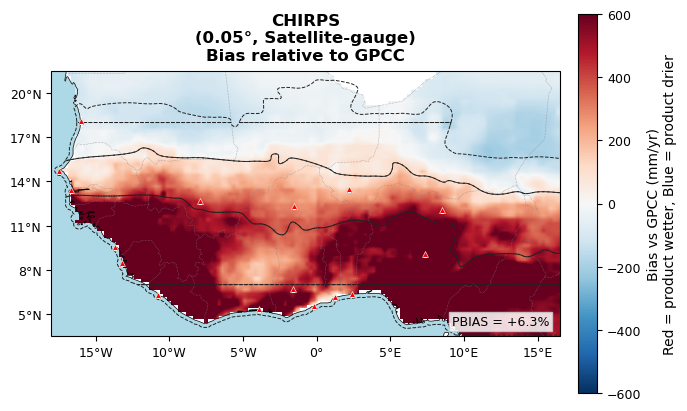

ERA5_LAND: bias range -1088.0 to 18413.8 mm/yr | mean bias = 244.9 mm/yr


c:\Users\Gebruiker\anaconda3\envs\geospatial\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Saved: bias_map_ERA5_LAND.png


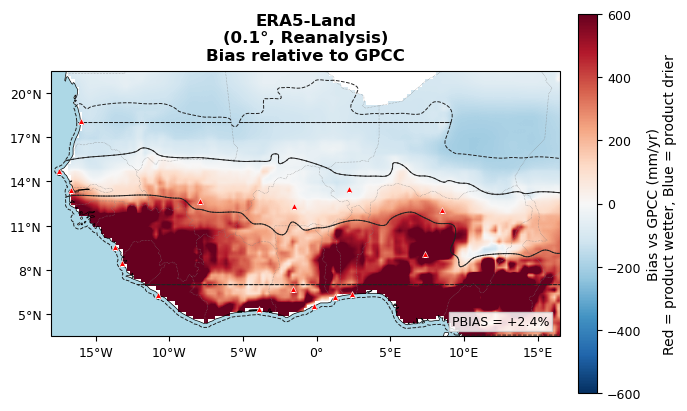

GPM_IMERG: bias range -1037.1 to 3239.1 mm/yr | mean bias = 318.3 mm/yr


c:\Users\Gebruiker\anaconda3\envs\geospatial\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Saved: bias_map_GPM_IMERG.png


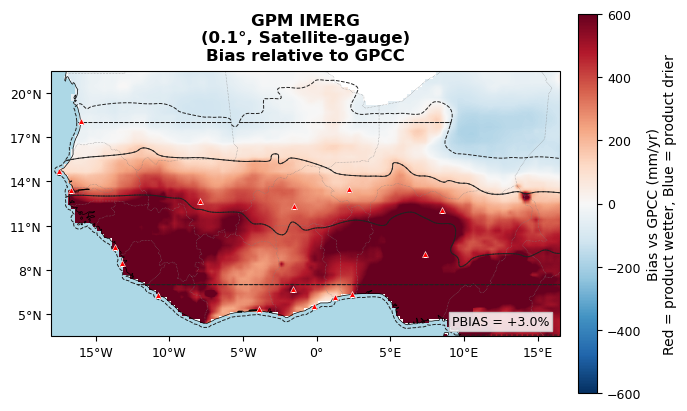

MERRA2: bias range -1391.5 to 2679.7 mm/yr | mean bias = 260.2 mm/yr


c:\Users\Gebruiker\anaconda3\envs\geospatial\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Saved: bias_map_MERRA2.png


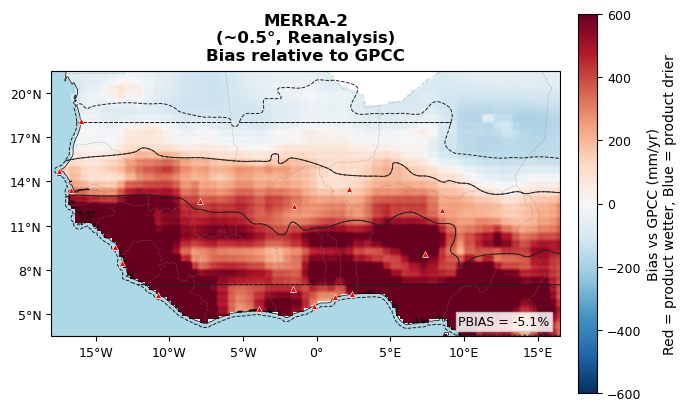

PERSIANN_CDR: bias range -1039.5 to 2175.3 mm/yr | mean bias = 324.0 mm/yr


c:\Users\Gebruiker\anaconda3\envs\geospatial\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Saved: bias_map_PERSIANN_CDR.png


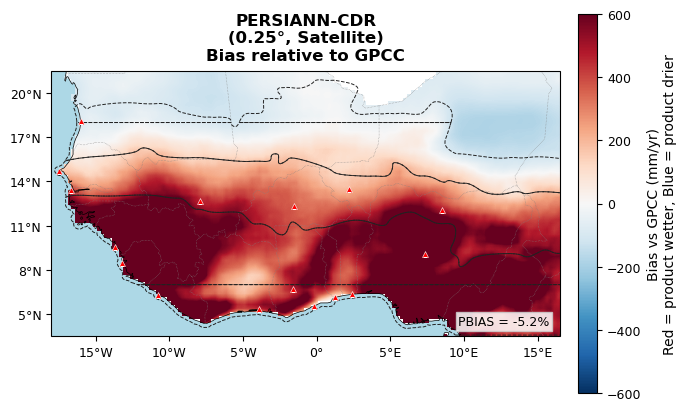

TERRACLIMATE: bias range -1128.6 to 3195.6 mm/yr | mean bias = 280.1 mm/yr


c:\Users\Gebruiker\anaconda3\envs\geospatial\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Saved: bias_map_TERRACLIMATE.png


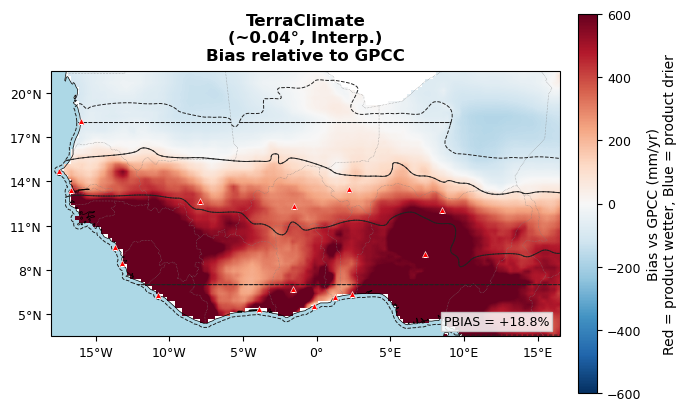

In [34]:
from matplotlib.colors import TwoSlopeNorm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import numpy as np
import pandas as pd
from scipy.ndimage import zoom

# =========================================================
# SETTINGS
# =========================================================
PROJ   = ccrs.PlateCarree()
EXTENT = [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]
XTICKS = [-15, -10, -5, 0, 5, 10, 15]
YTICKS = [5, 8, 11, 14, 17, 20]

BIAS_CMAP = 'RdBu_r'   # red = wetter than GPCC, blue = drier than GPCC
BIAS_MAX  = 600
bias_norm = TwoSlopeNorm(vmin=-BIAS_MAX, vcenter=0, vmax=BIAS_MAX)

# Products to plot individually
products = [
    ('CHIRPS',       PROD_LABELS['CHIRPS']),
    ('ERA5_LAND',    PROD_LABELS['ERA5_LAND']),
    ('GPM_IMERG',    PROD_LABELS['GPM_IMERG']),
    ('MERRA2',       PROD_LABELS['MERRA2']),
    ('PERSIANN_CDR', PROD_LABELS['PERSIANN_CDR']),
    ('TERRACLIMATE', PROD_LABELS['TERRACLIMATE']),
]

# Load validation file once
vo = pd.read_csv(DATA_DIR / 'validation_overall.csv')

# =========================================================
# HELPER FUNCTION
# =========================================================
def add_individual_map_elements(ax, title):
    ax.set_extent(EXTENT, crs=PROJ)

    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='black')
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=':', color='gray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='none', zorder=0)

    # Optional ecological zone boundaries
    if 'zones_gdf' in globals() and zones_gdf is not None:
        for _, zone in zones_gdf.iterrows():
            ax.add_geometries(
                [zone.geometry],
                crs=PROJ,
                facecolor='none',
                edgecolor='#222222',
                linewidth=0.7,
                linestyle='--',
                zorder=3
            )

    # Degree ticks
    ax.set_xticks(XTICKS, crs=PROJ)
    ax.set_yticks(YTICKS, crs=PROJ)
    ax.xaxis.set_major_formatter(LongitudeFormatter(degree_symbol='°'))
    ax.yaxis.set_major_formatter(LatitudeFormatter(degree_symbol='°'))
    ax.tick_params(labelsize=9)

    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)


# =========================================================
# LOOP: PLOT ONE MAP AFTER ANOTHER
# =========================================================
for prod_key, title in products:
    tif = MAPS_DIR / f'map_mean_annual_{prod_key}.tif'

    if not tif.exists():
        print(f'{prod_key} not found: {tif}')
        continue

    # Load product data
    prod_data, prod_extent = load_tif(tif)

    # Regrid GPCC to product resolution
    if gpcc_data.shape != prod_data.shape:
        zy = prod_data.shape[0] / gpcc_data.shape[0]
        zx = prod_data.shape[1] / gpcc_data.shape[1]
        gpcc_resized = zoom(gpcc_data, (zy, zx), order=1, prefilter=False)
    else:
        gpcc_resized = gpcc_data

    # Compute bias
    bias = prod_data - gpcc_resized

    # Mask invalid values to avoid ugly spreading of gaps
    if np.ma.isMaskedArray(bias):
        plot_bias = bias
    else:
        plot_bias = np.ma.masked_invalid(bias)

    print(f'{prod_key}: bias range {np.nanmin(bias):.1f} to {np.nanmax(bias):.1f} mm/yr'
          f' | mean bias = {np.nanmean(bias):.1f} mm/yr')

    # Create figure
    fig = plt.figure(figsize=(8, 6))
    ax = plt.axes(projection=PROJ)

    add_individual_map_elements(ax, f'{title}\nBias relative to GPCC')

    # Plot bias map
    im = ax.imshow(
        plot_bias,
        origin='upper',
        extent=prod_extent,
        transform=PROJ,
        cmap=BIAS_CMAP,
        norm=bias_norm,
        interpolation='bilinear',   # or 'nearest' if you want sharper edges
        resample=False,
        zorder=1
    )

    # Plot stations if function exists
    if 'plot_stations' in globals():
        plot_stations(ax)

    # Add PBIAS annotation
    pbias_val = vo.loc[vo['product'] == prod_key, 'pbias'].values
    if len(pbias_val):
        ax.text(
            0.98, 0.03,
            f'PBIAS = {pbias_val[0]:+.1f}%',
            transform=ax.transAxes,
            fontsize=9,
            ha='right',
            va='bottom',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='#cccccc', pad=2)
        )

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.82, pad=0.03)
    cbar.set_label('Bias vs GPCC (mm/yr)\nRed = product wetter, Blue = product drier', fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    # Optional save
    out_file = FIGS_DIR / f'bias_map_{prod_key}.png'
    fig.savefig(out_file, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Saved: {out_file.name}')

    plt.show()

## Optional Map 3 — Inter-product standard deviation (mm/yr)

Shows pixel-wise disagreement across all 6 products.  
High std dev = where ensemble approach is most needed.

c:\Users\Gebruiker\anaconda3\envs\geospatial\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\Gebruiker\anaconda3\envs\geospatial\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Inter-product std dev: mean=104 max=6659 mm/yr
Saved: map03_interproduct_std.png


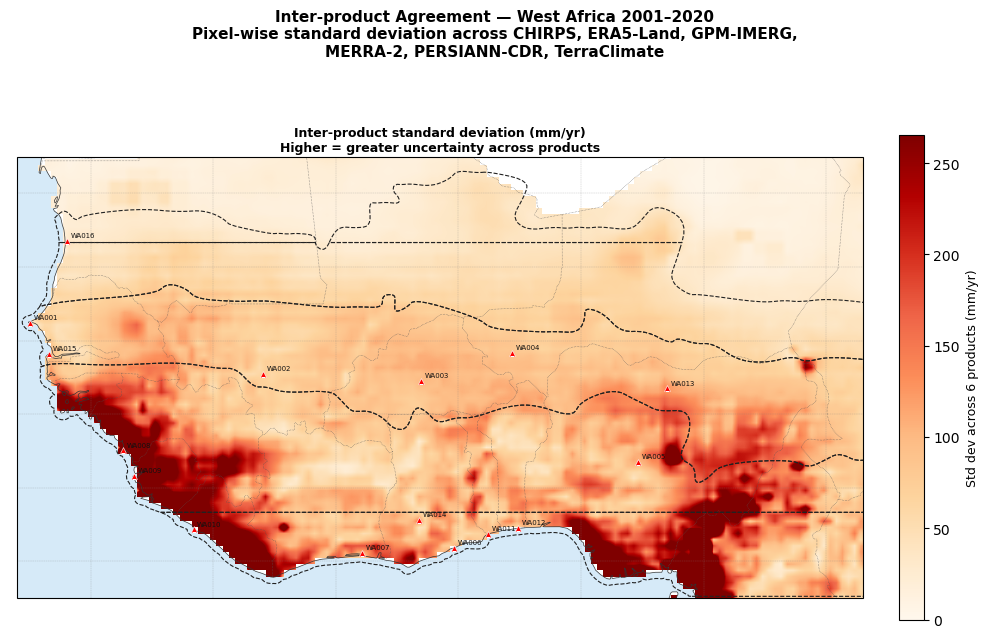

In [7]:
# Load all product rasters at a common resolution
# Use CHIRPS grid as reference (finest resolution)
from scipy.ndimage import zoom

ref_tif = MAPS_DIR / 'map_mean_annual_CHIRPS.tif'
if not ref_tif.exists():
    print('CHIRPS GeoTIFF not found — skipping Map 3')
else:
    ref_data, ref_extent = load_tif(ref_tif)
    target_shape = ref_data.shape

    stacked = [ref_data]
    for prod in ['ERA5_LAND','GPM_IMERG','MERRA2','PERSIANN_CDR','TERRACLIMATE']:
        tif = MAPS_DIR / f'map_mean_annual_{prod}.tif'
        if not tif.exists():
            print(f'  Missing {prod} — skipping')
            continue
        data, _ = load_tif(tif)
        if data.shape != target_shape:
            zy = target_shape[0] / data.shape[0]
            zx = target_shape[1] / data.shape[1]
            data = zoom(data, (zy, zx), order=1, prefilter=False)
        stacked.append(data)

    std_map = np.nanstd(np.stack(stacked, axis=0), axis=0)
    print(f'Inter-product std dev: mean={np.nanmean(std_map):.0f} '
          f'max={np.nanmax(std_map):.0f} mm/yr')

    fig3, ax3 = plt.subplots(1, 1, figsize=(10, 7),
                              subplot_kw={'projection': PROJ})
    fig3.patch.set_facecolor('white')

    add_map_elements(ax3,
        'Inter-product standard deviation (mm/yr)\nHigher = greater uncertainty across products',
        show_ylabel=True, show_xlabel=True)

    im3 = ax3.imshow(
        std_map, origin='upper', extent=ref_extent,
        transform=PROJ, cmap='OrRd',
        vmin=0, vmax=np.nanpercentile(std_map, 95),
        interpolation='bilinear', zorder=1
    )
    plot_stations(ax3, label_stations=True)

    cbar3 = fig3.colorbar(im3, ax=ax3, orientation='vertical',
                          fraction=0.03, pad=0.04, shrink=0.8)
    cbar3.set_label('Std dev across 6 products (mm/yr)', fontsize=9)

    fig3.suptitle(
        'Inter-product Agreement — West Africa 2001–2020\n'
        'Pixel-wise standard deviation across CHIRPS, ERA5-Land, GPM-IMERG,\n'
        'MERRA-2, PERSIANN-CDR, TerraClimate',
        fontsize=11, fontweight='bold'
    )
    fig3.tight_layout()
    out3 = FIGS_DIR / 'map03_interproduct_std.png'
    fig3.savefig(out3, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Saved: {out3.name}')
    plt.show()


## Requirements

```bash
pip install cartopy rasterio scipy geopandas xarray matplotlib earthengine-api
```

**Cartopy on Windows**: if `pip install cartopy` fails, use conda:
```bash
conda install -c conda-forge cartopy -n precip
```

**GeoTIFF download order**:
1. Run the GEE export cell
2. Wait for all 6 tasks to complete (~5–15 min each)
3. Download from Google Drive folder `WA_Maps` to your `MAPS_DIR`
4. Run Step 2 (GPCC from local .nc files)
5. Run Steps 3–4 (load + plot)

**Tweak parameters**:
- `VMIN / VMAX`: colorbar range for Map 1 (mm/yr)
- `BIAS_MAX`: symmetric colorbar range for Map 2
- `XTICKS / YTICKS`: coordinate tick positions in degrees
- `label_stations=True` on any panel to show station IDs
- `SCALE`: GEE export resolution in metres (27830 ≈ 0.25°)